In [19]:
from FormUtils import  pyForm, capture_physics_expr

In [20]:
%%pyForm ee_to_mumu_massless

*------------------------------------------------------------------
* The gamma matrices fulfill the relations:
*    {g_(j1,mu),g_(j1,nu)} = 2 * d_(mu,nu)
*    [g_(j1,mu),g_(j2,nu)] = 0    j1 not equal to j2.
* 
* Dirac Algebra Basis (Bilinear Covariants) :
*   gi_(j)                : Scalar (Unit matrix)
*   g_(j,mu)              : Vector
*   [g_(j,mu),g_(j,nu)]/2 : Tensor
*   g5_(j)*g_(j,mu)       : Axial-Vector
*   g5_(j)                : Pseudoscalar
* ------------------------------------------------------------------

* Process: e+ e- -> mu+ mu-

* Indices 
Indices mu, nu, rho, sigma;

* Kinematic variables
Symbols s, t, u;

* Physical constants
Symbols e, pi, alpha;

* Four-vectors
Vectors p1, p2, p3, p4;

* Three momenta ratio in CM
Symbols pfInOutRatio;


* ------------------------------------------------------------------
*  Matrix Element Squared for e+(p2) e-(p1) -> mu+(p3) mu-(p4)
*  Massless case
* (|M|^2) = (e^4 / s^2) * g^{mu nu} * g^{rho sigma} *
*            Tr[slash(p2) * gamma_mu  * slash(p1) * gamma_rho ] *
*            Tr[slash(p3) * gamma_nu * slash(p4) * gamma_sigma]
*  g_(1,...) is Electron current ; g_(2,...) is Muon current
* Photon Propagator contracts one electron vertex with a Muon one
* ------------------------------------------------------------------ 
Local Msq = (e^4 / s^2) * d_(mu, nu) * d_(rho, sigma) * 
            (g_(1, p2) * g_(1, mu) * g_(1, p1) * g_(1, rho)) * 
            (g_(2, p3) * g_(2, nu) * g_(2, p4) * g_(2, sigma));


.sort
trace4, 1;
trace4, 2;
.sort
contract;
Print Msq;
.sort

* Physics & Normalization
id e^4 = 16 * pi^2 * alpha^2;
* Spin averaging (1/2 * 1/2)
multiply 1/4; 

* 3. Kinematics 
* Repeat substitutions as needed.
* We form all Mandelstam 
* Note that here what happens
* is symbolic substitution

repeat;

    id p1.p1 = 0;
    id p2.p2 = 0;
    id p3.p3 = 0;
    id p4.p4 = 0;
    
    id p1.p2 = (s - p1.p1 - p2.p2)/2;
    id p3.p4 = (s - p3.p3 - p4.p4)/2;
    
    
    id p1.p3 = (p1.p1 + p3.p3 - t)/2;
    id p2.p4 = (p2.p2 + p4.p4 - t)/2;

   
    id p1.p4 = (p1.p1 + p4.p4 - u)/2;
    id p2.p3 = (p2.p2 + p3.p3 - u)/2;
endrepeat;
.sort

* Differential cross section formula
Local dSigma = (1 / (64 * pi^2 * s)) * pfInOutRatio * Msq;
.sort

bracket alpha, s, pfInOutRatio;
* Print and save in Fortran format
Format Fortran;
Print Msq;
Print dSigma;
#write <ee_to_mumu_noM.txt> "%e;", dSigma;
.sort

* Print in FORM format factorized
Format;
factorize;
Print Msq;
Print dSigma;
.sort
.end

.end

FORM 5.0.0 (Jan 27 2026, v5.0.0)                 Run: Wed Apr  8 17:06:50 2026
    
    *------------------------------------------------------------------
    * The gamma matrices fulfill the relations:
    *    {g_(j1,mu),g_(j1,nu)} = 2 * d_(mu,nu)
    *    [g_(j1,mu),g_(j2,nu)] = 0    j1 not equal to j2.
    * 
    * Dirac Algebra Basis (Bilinear Covariants) :
    *   gi_(j)                : Scalar (Unit matrix)
    *   g_(j,mu)              : Vector
    *   [g_(j,mu),g_(j,nu)]/2 : Tensor
    *   g5_(j)*g_(j,mu)       : Axial-Vector
    *   g5_(j)                : Pseudoscalar
    * ------------------------------------------------------------------
    
    * Process: e+ e- -> mu+ mu-
    
    * Indices 
    Indices mu, nu, rho, sigma;
    
    * Kinematic variables
    Symbols s, t, u;
    
    * Physical constants
    Symbols e, pi, alpha;
    
    * Four-vectors
    Vectors p1, p2, p3, p4;
    
    * Three momenta ratio in CM
    Symbols pfInOutRatio;
    
    
    * ------------

Captured Expression: 1./2.*s**(-3)*u**2*alpha**2*pfInOutRatio+1./2.*s**(-3)*t**2*alpha**2*pfInOutRatio


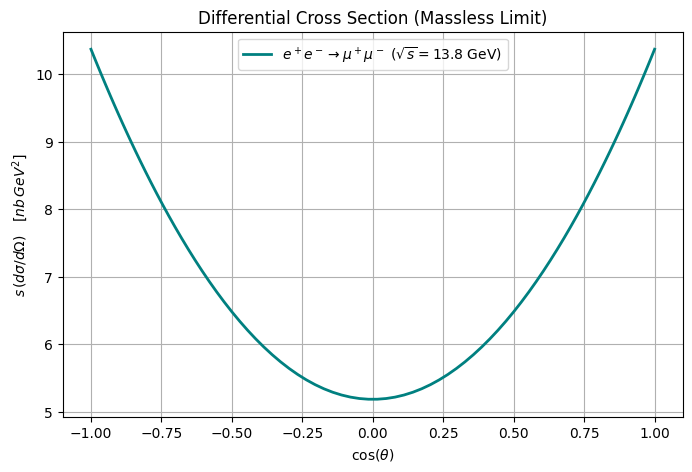

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from Kinematics import  kinematics2To2

plt.style.use('seaborn-v0_8-muted') 
plt.rcParams['axes.grid'] = True


# Capture 
py_expr = capture_physics_expr("scripts/ee_to_mumu_noM.txt")
print(f"Captured Expression: {py_expr}")

#Inputs
sqrtS = 13.8
alpha = 1/137.036
# Conversion Factors from Natural Units to Cross-Section 
# (0.197327 GeV * fm)^2 = 0.0389379 GeV^2 * fm^2
# 1 GeV^-2 = 0.389379 mb (millibarns)
conv_gev2_to_nb = 389379.0

# Fill values for Plotting
angles = np.linspace(0, np.pi, 100)
x_vals = np.cos(angles)
s_val, t_vals, u_vals, ratio_val = kinematics2To2(sqrtS, angles)
y_vals = eval(py_expr, {
    "s": s_val, 
    "t": t_vals, 
    "u": u_vals, 
    "alpha": alpha,
    "pfInOutRatio" : ratio_val
})
y_vals = (sqrtS**2) * y_vals * conv_gev2_to_nb


# Plot
plt.figure(figsize=(8, 5))
plt.plot(x_vals, y_vals, lw=2, color='teal', label=rf'$e^+e^- \to \mu^+\mu^-$ ($\sqrt{{s}}={(sqrtS)}$ GeV)')
plt.title("Differential Cross Section (Massless Limit)")
plt.xlabel(r"$\cos(\theta)$")
plt.ylabel(r"$s\, (d\sigma/d\Omega)\quad [nb\, GeV^2]$ ")
plt.legend()
plt.show()
    
